<h2 style="color:black" align="center">Handwritten digits classification using CNN</h2>

In this notebook we will classify handwritten digits using a simple neural network (ANN) first and than repeat same thing with convolutional neural network. We will see how accuracy improves clickly when you use convolutional neural network.

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [28]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [29]:
X_train.shape

(60000, 28, 28)

In [30]:
X_test.shape

(10000, 28, 28)

In [31]:
X_train[0].shape

(28, 28)

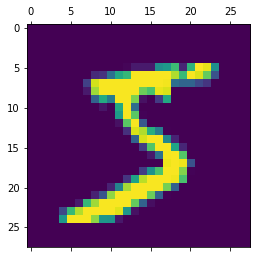

In [32]:
plt.matshow(X_train[0])

In [33]:
y_train[0]

5

In [34]:
X_train = X_train / 255
X_test = X_test / 255

<h3 style='color:black'>Using ANN for classification</h3>

In [10]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 924us/step - loss: 0.2885 - accuracy: 0.9194
Epoch 2/10
1875/1875 [==============================] - 2s 920us/step - loss: 0.1363 - accuracy: 0.9603
Epoch 3/10
1875/1875 [==============================] - 2s 925us/step - loss: 0.0993 - accuracy: 0.9704
Epoch 4/10
1875/1875 [==============================] - 2s 929us/step - loss: 0.0765 - accuracy: 0.9771
Epoch 5/10
1875/1875 [==============================] - 2s 943us/step - loss: 0.0620 - accuracy: 0.9808
Epoch 6/10
1875/1875 [==============================] - 2s 938us/step - loss: 0.0509 - accuracy: 0.9843
Epoch 7/10
1875/1875 [==============================] - 2s 956us/step - loss: 0.0414 - accuracy: 0.9876
Epoch 8/10
1875/1875 [==============================] - 2s 971us/step - loss: 0.0363 - accuracy: 0.9887
Epoch 9/10
1875/1875 [==============================] - 2s 961us/step - loss: 0.0301 - accuracy: 0.9905
Epoch 10/10
1875/1875 [==============================] - 2s 963u

In [11]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 988us/step - loss: 0.0831 - accuracy: 0.9780


[0.0830635279417038, 0.9779999852180481]

In [35]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [40]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

<h3 style='color:black'>Using CNN for classification</h3>

In [59]:
model = keras.Sequential([
    
    layers.Conv2D(30, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
 
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

In [60]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.1739 - accuracy: 0.9488
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0610 - accuracy: 0.9814
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0398 - accuracy: 0.9872
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0291 - accuracy: 0.9909
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0207 - accuracy: 0.9934


In [61]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [56]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.0541 - accuracy: 0.9843


[0.05414153262972832, 0.9843000173568726]

C:\Users\dell\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 90s 140ms/step - accuracy: 0.6383 - loss: 1.4688 - val_accuracy: 0.9725 - val_loss: 0.2095 - learning_rate: 0.0010
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 61s 101ms/step - accuracy: 0.9236 - loss: 0.3711 - val_accuracy: 0.9823 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 55s 92ms/step - accuracy: 0.9456 - loss: 0.2687 - val_accuracy: 0.9749 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 67s 111ms/step - accuracy: 0.9556 - loss: 0.2276 - val_accuracy: 0.9846 - val_loss: 0.1087 - learning_rate: 0.0010
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 76s 127ms/step - accuracy: 0.9592 - loss: 0.2086 - val_accuracy: 0.9892 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 75s 124ms/step - accuracy: 0.9651 - loss: 0.1909 - val_accuracy: 0.9894 - val_loss: 0.0936 - learning_rate: 0.0010
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.967

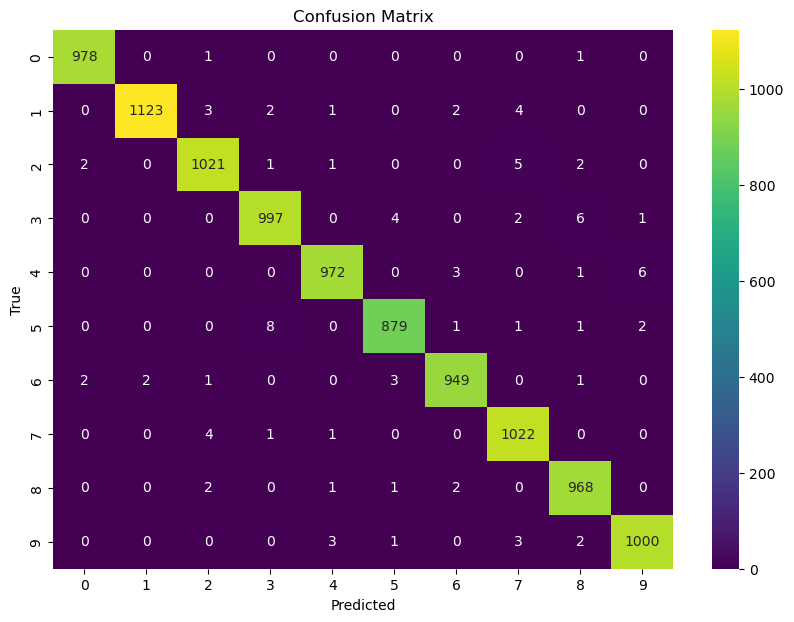

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0  # Normalize to [0, 1]
X_test = X_test.astype('float32') / 255.0

# Reshape data
X_train = np.reshape(X_train, (X_train.shape[0], 28, 28, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 28, 28, 1))

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)

# Build the CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Use Input layer to specify the input shape
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)
early_stopper = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)  # Changed to .keras

# Fit the model with data augmentation
history = model.fit(datagen.flow(X_train, y_train, batch_size=100),
                    epochs=10,
                    validation_data=(X_test, y_test),
                    callbacks=[lr_reducer, early_stopper, checkpoint])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion Matrix
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')  # Use a valid colormap like 'Greens'
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

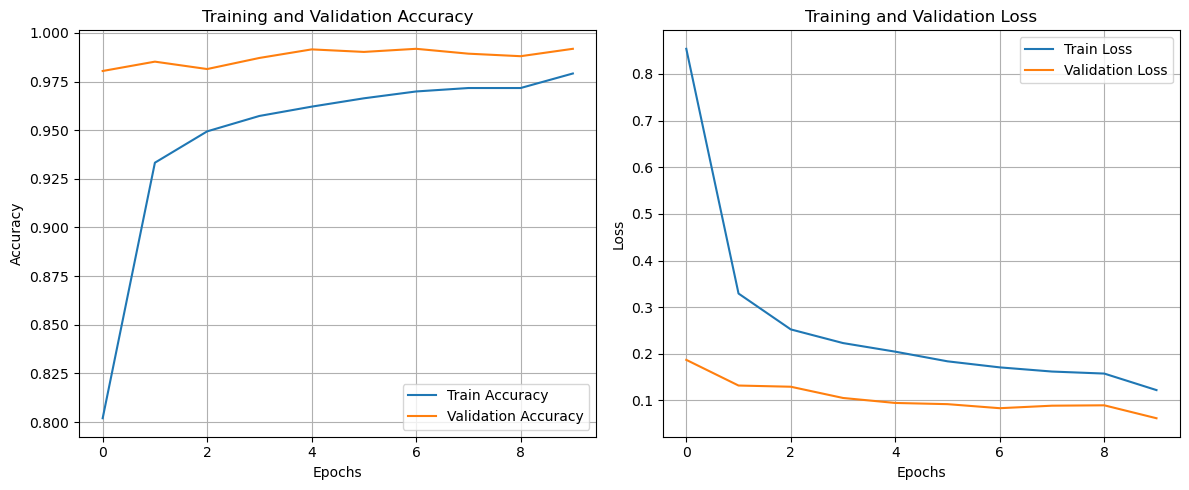

In [6]:
import matplotlib.pyplot as plt

# Assuming `history` is the object returned by model.fit()
# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

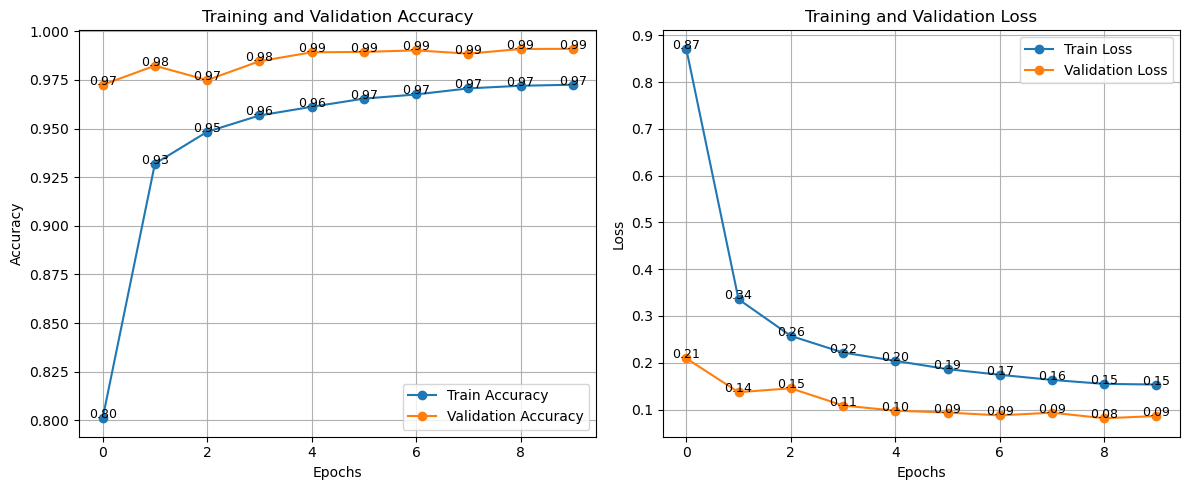

In [8]:
import matplotlib.pyplot as plt

# Assuming `history` is the object returned by model.fit()
# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Annotate accuracy values
for i, acc in enumerate(history.history['accuracy']):
    plt.text(i, acc, f"{acc:.2f}", fontsize=9, ha='center')
for i, val_acc in enumerate(history.history['val_accuracy']):
    plt.text(i, val_acc, f"{val_acc:.2f}", fontsize=9, ha='center')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Annotate loss values
for i, loss in enumerate(history.history['loss']):
    plt.text(i, loss, f"{loss:.2f}", fontsize=9, ha='center')
for i, val_loss in enumerate(history.history['val_loss']):
    plt.text(i, val_loss, f"{val_loss:.2f}", fontsize=9, ha='center')

plt.tight_layout()
plt.show()